In [1]:
import gymnasium as gym
import numpy as np
from typing import Optional, Tuple, Any
import sys
sys.path.append("..")

import tools.robots as robots
import tools.envs.navigation_envs as navigation_envs
import tools.planners as planners
from tools.utils.plot_graph import plot_graph_2d

from time import sleep

#
from gymnasium.utils.env_checker import check_env

import logging
logging.basicConfig(level=logging.DEBUG)
logger = logging.getLogger(__name__)

Successfully registered NavigationEnvBrokenRudder-v0


In [2]:
gym.register(
    id='NavigationEnvSingleIntegratorUnicycleSpace-v0',
    entry_point='tools.envs.navigation_envs.navigation_env_single_integrator_unicycle_space:NavigationEnvSingleIntegratorUnicycleSpace',)

gym.register(
    id='TestCycleEnv-v0',
    entry_point='tools.envs.test_cycle_env:TestCycleEnv',)

# env = gym.make('NavigationEnvSingleIntegratorUnicycleSpace-v0', render_mode="human", multi_step_count=15)

env = gym.make('TestCycleEnv-v0', render_mode="human", multi_step_count=10, atol=0.05, default_step_divisor=1)
# 

/home/christoph/Dokumente/research/projects/dec-mcgs/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='human' that is not in the possible render_modes ([]).
  logger.warn(
/home/christoph/Dokumente/research/projects/dec-mcgs/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/christoph/Dokumente/research/projects/dec-mcgs/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
INFO:tools.robots.single_integrator_unicycle_space:Starting initialization of SingleIntegratorUnicycleSpace
INFO:tools.robots.single_integrator_unicycle:Starting initialization of SingleIntegratorUnicycle
INFO:tools.robots.single_integrator_unicycle:Finished initiali

---- Starting Initialization of NavigationEnvSingleIntegratorUnicycleSpace
Starting initialization of SingleIntegrator
Finished initialization of SingleIntegrator
---- Finished Initialization of NavigationEnvSingleIntegratorUnicycle


In [3]:
env.unwrapped.agent.state

array([-3.5068753, -0.7811597,  2.197322 ,  0.       ], dtype=float32)

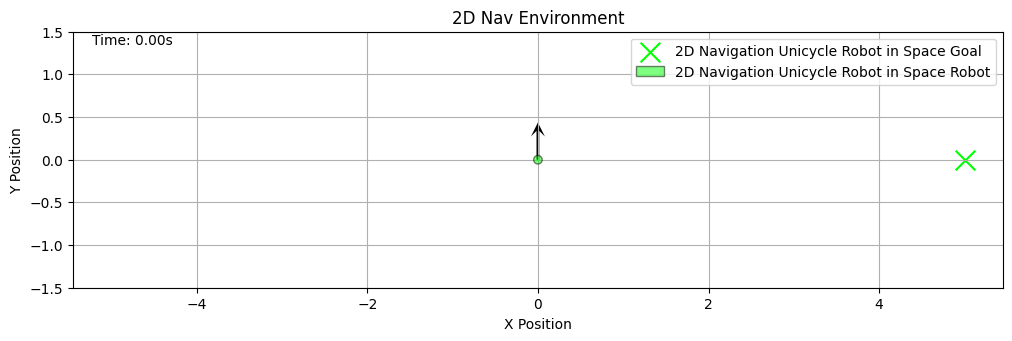

<Figure size 1200x1200 with 0 Axes>

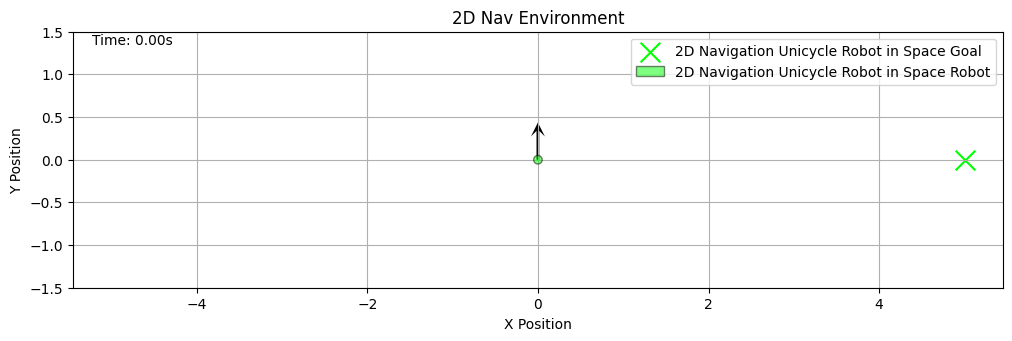

In [4]:
env.reset(seed=42)
env.render()

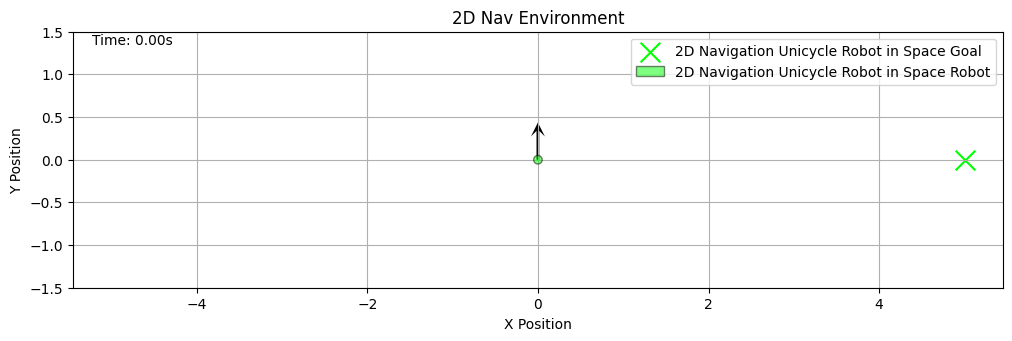

/home/christoph/Dokumente/research/projects/dec-mcgs/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='ansi' that is not in the possible render_modes ([]).
  logger.warn(
INFO:tools.robots.single_integrator_unicycle_space:Starting initialization of SingleIntegratorUnicycleSpace
INFO:tools.robots.single_integrator_unicycle:Starting initialization of SingleIntegratorUnicycle
INFO:tools.robots.single_integrator_unicycle:Finished initialization of SingleIntegratorUnicycle
INFO:tools.robots.single_integrator_unicycle_space:Finished initialization of SingleIntegratorUnicycleSpace
INFO:tools.robots.single_integrator_unicycle_space:Starting initialization of SingleIntegratorUnicycleSpace
INFO:tools.robots.single_integrator_unicycle:Starting initialization of SingleIntegratorUnicycle
INFO:tools.robots.single_integrator_unicycle:Finished initialization of SingleIntegratorUnicycle
INFO:tools.robots.sing

---- Starting Initialization of NavigationEnvSingleIntegratorUnicycleSpace
Starting initialization of SingleIntegrator
Finished initialization of SingleIntegrator
---- Finished Initialization of NavigationEnvSingleIntegratorUnicycle
---- Starting Initialization of NavigationEnvSingleIntegratorUnicycleSpace
Starting initialization of SingleIntegrator
Finished initialization of SingleIntegrator
---- Finished Initialization of NavigationEnvSingleIntegratorUnicycle


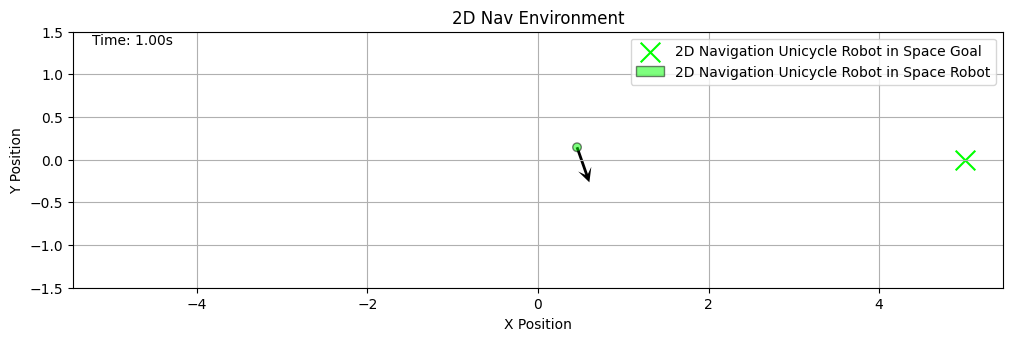

<Figure size 1200x1200 with 0 Axes>

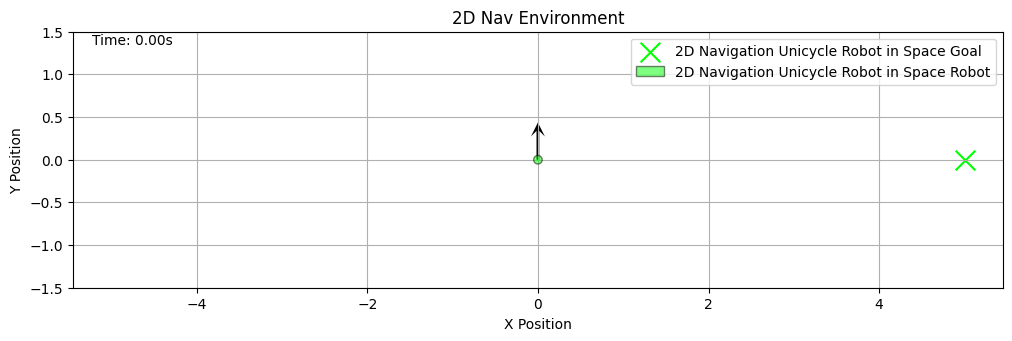

<Figure size 1200x1200 with 0 Axes>

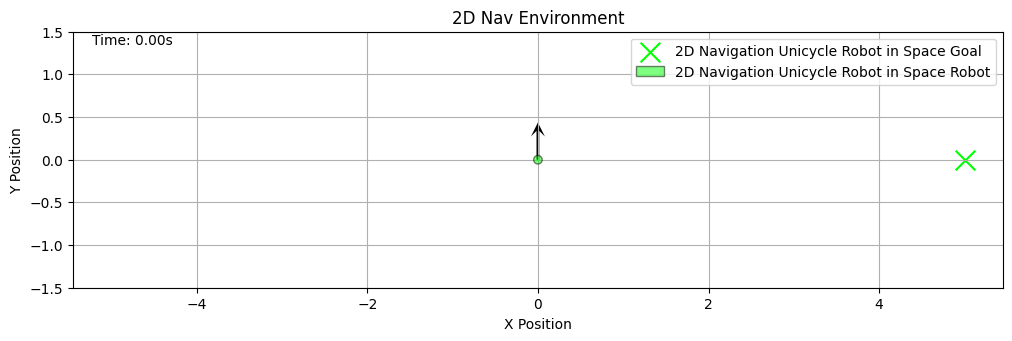

In [5]:

check_env(env.unwrapped, warn=True)

In [6]:
env.unwrapped.agent.state_goal  # Sample an action to test the action space

array([ 5.,  0., nan, nan], dtype=float32)

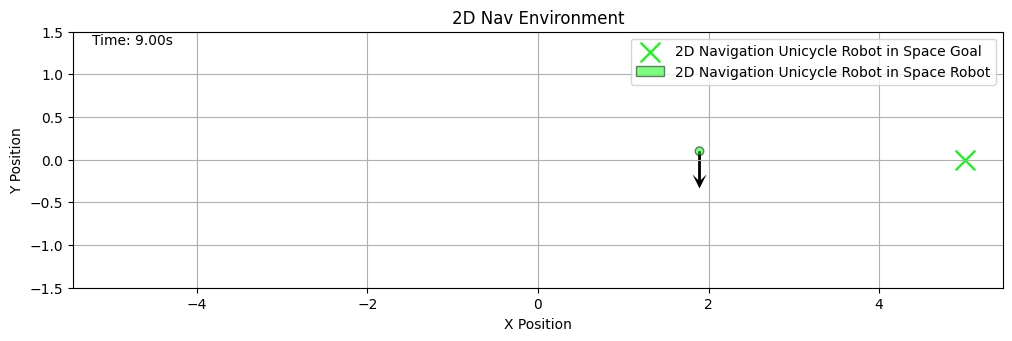

Action: [ 1.        -3.1415927]
Observation: [ 1.2627487e+00 -4.1350722e-06  1.5707982e+00  1.0000002e+01]
Reward: 0.01
Terminated: False
Truncated: False
Obs is in observation space: True Box([-5.25      -1.5       -3.1415927  0.       ], [5.25      1.5       3.1415927       inf], (4,), float32)
Info: {'states_visited': [array([ 1.8941238e+00, -2.7269125e-06, -1.8849531e+00,  9.0999985e+00],
      dtype=float32), array([ 1.8632224 , -0.09510846, -2.1991124 ,  9.199999  ], dtype=float32), array([ 1.8044441 , -0.17601031, -2.5132718 ,  9.299999  ], dtype=float32), array([ 1.7235425 , -0.23478903, -2.8274312 ,  9.4       ], dtype=float32), array([ 1.6284369 , -0.26569092, -3.1415906 ,  9.5       ], dtype=float32), array([ 1.5284369 , -0.26569113,  2.8274357 ,  9.6       ], dtype=float32), array([ 1.4333311 , -0.23478965,  2.5132763 ,  9.700001  ], dtype=float32), array([ 1.3524293 , -0.17601131,  2.199117  ,  9.800001  ], dtype=float32), array([ 1.2936506 , -0.09510973,  1.8849576 ,  9.9

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

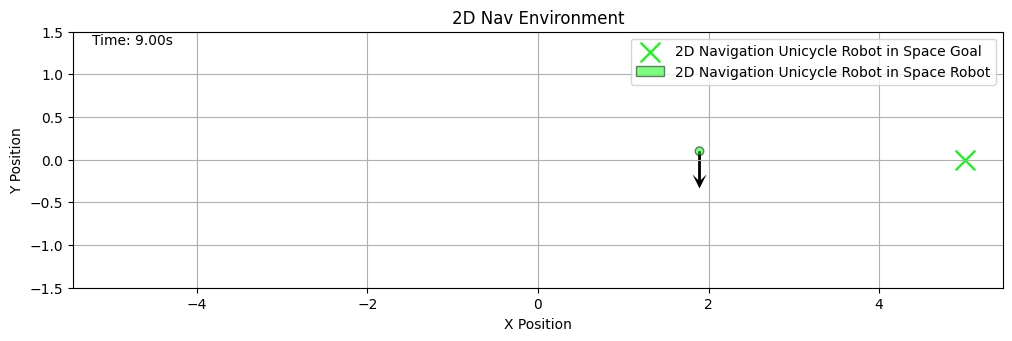

In [7]:
env.reset()
for _ in range(10):
    action = env.unwrapped.agent.sample_action()
    # action = -1*np.ones_like(action)
    # sleep(2.0)
    env.render()
    # sleep(2.0)
    obs, reward, terminated, truncated, info = env.step(action)

    print("Action:", action)

   
    print("Observation:", obs)
    print("Reward:", reward)
    print("Terminated:", terminated)
    print("Truncated:", truncated)
    print("Obs is in observation space:", env.observation_space.contains(obs), env.observation_space)
    print("Info:", info)
    sleep(0.1)

    if terminated or truncated:
        
        print("Episode finished after {} timesteps".format(info['steps_taken']+1))
        print(terminated, truncated)
        env.reset()
        
        # break

In [8]:
computational_budget_max = 30
time_budget_max = 100.0

In [9]:
planner = planners.MCGSPlanner(env=env.unwrapped,
                               computational_budget_max=computational_budget_max,
                               time_budget_max=time_budget_max,
                               expand_n_times=1,
                               expand_n_times_min=1,
                               expand_n_times_max=1,
                               kappa=2.0,
                               alpha=0.0,
                               gamma=0.99,
                               k=5,
                               radius_threshold=1.0,
                               progressive_widening_method="default",
                               abstraction_refinement_exponent=-0.0,
                               c_uct=0.5,
                               plan_in_space_time=False,
                               use_controller=True,
                               tracking_tolerance=0.5,
                               yield_mode='N',
                               random_rollout_n_times=1,
                               random_rollout_length=5,
                               force_exact_update=True,)

In [10]:
planner.reset(seed=123)
print(planner.graph.num_nodes(), planner.hnsw_index.get_current_count())
planner.plan(30)
try:
    planner.plan(0)
except Exception as e:
    print(f"Error occurred: {e}")   


1 1
Current node: 0 with successors NodeIndices[2, 1]
Selecting child of node 0 with N=3, X=2, children=2
UCT values: [[2.         0.58308349]
 [1.         0.58308349]]

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Success: True, n_actions: 10, sum_dt: 4.228517837413033, start_state: [-0.6313751   0.09999976 -1.5707958   1.0000001 ], setpoint_state: [0.        0.        1.5707964 0.       ], final_state: [2.89944535e-09 1.14894544e-09 1.57079637e+00 5.22851796e+00], would_truncate: False
True Start: [-0.6313751   0.09999976 -1.5707958   1.0000001 ] Controller: [2.89944535e-09 1.14894544e-09 1.57079637e+00 5.22851796e+00] Setpoint: [0.        0.       

In [11]:
res = planner.yield_plan()
print(res)
planner.update_trajectory_plan(*res)

Best edge tuple: (0, 1, EdgePayload(actions=[array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32)], dt=[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], Q=None))
Best edge tuple: (1, 4, EdgePayload(actions=[array([1.       , 3.1415927], dtype=float32), array([1.       , 3.1415927], dtype=float32), array([1.       , 3.1415927], dtype=float32), array([1.       , 3.1415927], dtype=float32), array([1.       , 3.1415927], dtype=float32), array([1.       , 3.1415927], dtype=float32), array([1.       , 3.1415927], dtype=float32), array([1.       , 3.1415927], dtype=float32

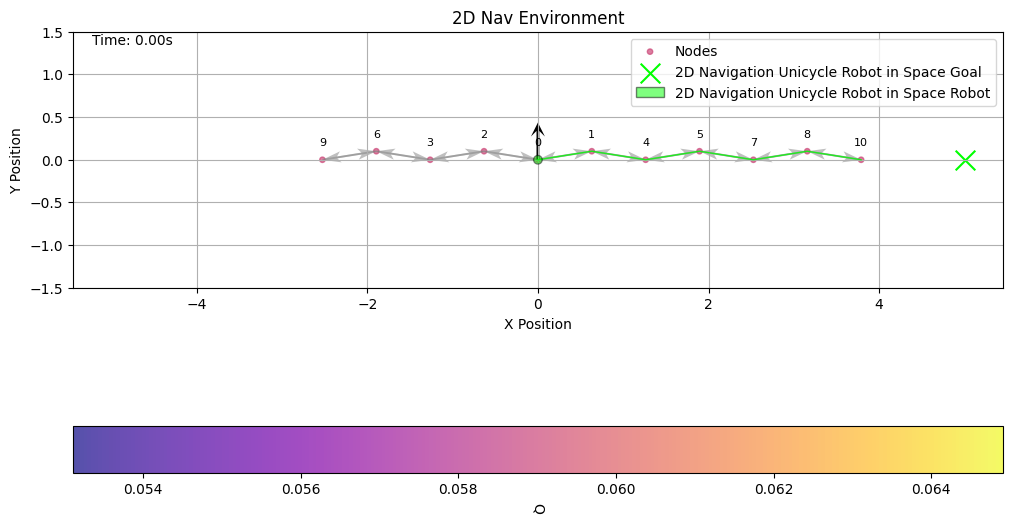

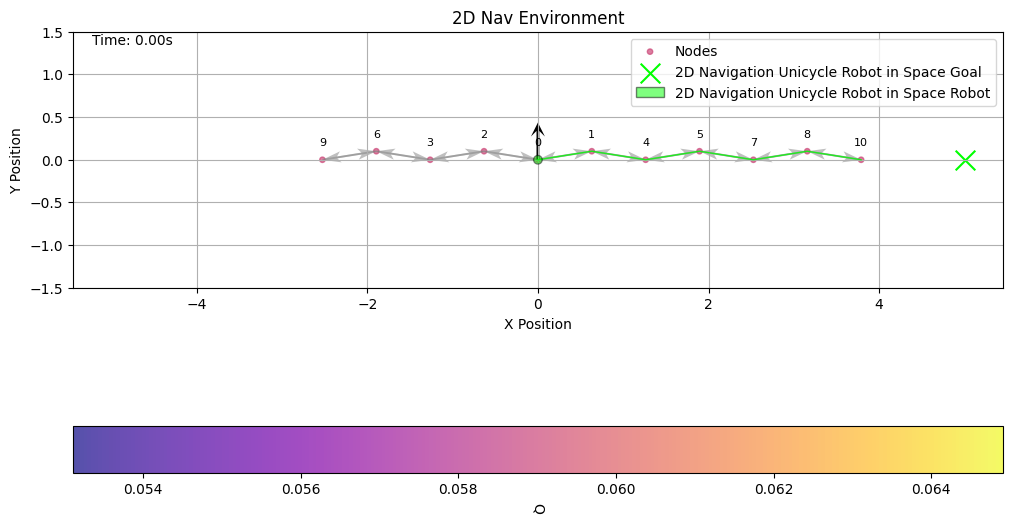

In [12]:
try:
    planner.render(scatter_mode='Q')
except Exception as e:
    print(f"Error occurred while rendering: {e}")   


In [13]:
u = planner.graph.successor_indices(0)
[print(planner.graph[n]) for n in u]
[print(planner.graph[node]) for node in planner.graph.node_indices()]
[print(edge.N) for edge in planner.graph.edges()]
print(planner.graph.num_nodes())
print(planner.graph.num_edges())

NodePayload(id=2, state=[-0.6313751   0.09999976 -1.5707958   1.0000001 ], N=15, U=0.0590099501, Q=0.0590099501, is_finished=False, is_truncated=False)
NodePayload(id=1, state=[ 0.631375    0.09999954 -1.5707974   1.0000001 ], N=15, U=0.0590099501, Q=0.0590099501, is_finished=False, is_truncated=False)
NodePayload(id=0, state=[0.        0.        1.5707964 0.       ], N=31, U=0.0590099501, Q=0.0590099501, is_finished=False, is_truncated=False)
NodePayload(id=1, state=[ 0.631375    0.09999954 -1.5707974   1.0000001 ], N=15, U=0.0590099501, Q=0.0590099501, is_finished=False, is_truncated=False)
NodePayload(id=2, state=[-0.6313751   0.09999976 -1.5707958   1.0000001 ], N=15, U=0.0590099501, Q=0.0590099501, is_finished=False, is_truncated=False)
NodePayload(id=3, state=[-1.2627501e+00 -4.6938658e-07  1.5707963e+00  2.0000002e+00], N=11, U=0.0590099501, Q=0.0590099501, is_finished=False, is_truncated=False)
NodePayload(id=4, state=[ 1.2627498e+00 -9.0152025e-07  1.5707963e+00  2.0000002e+00

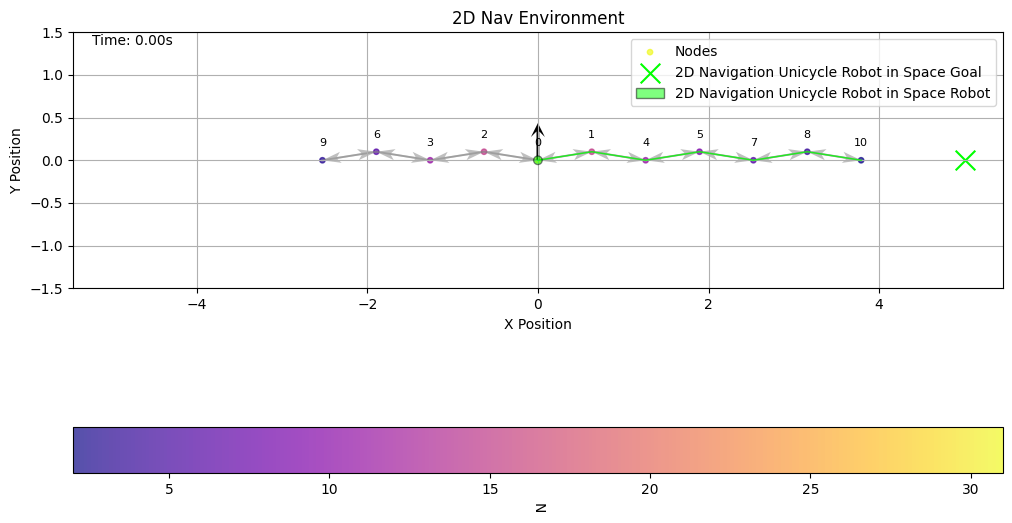

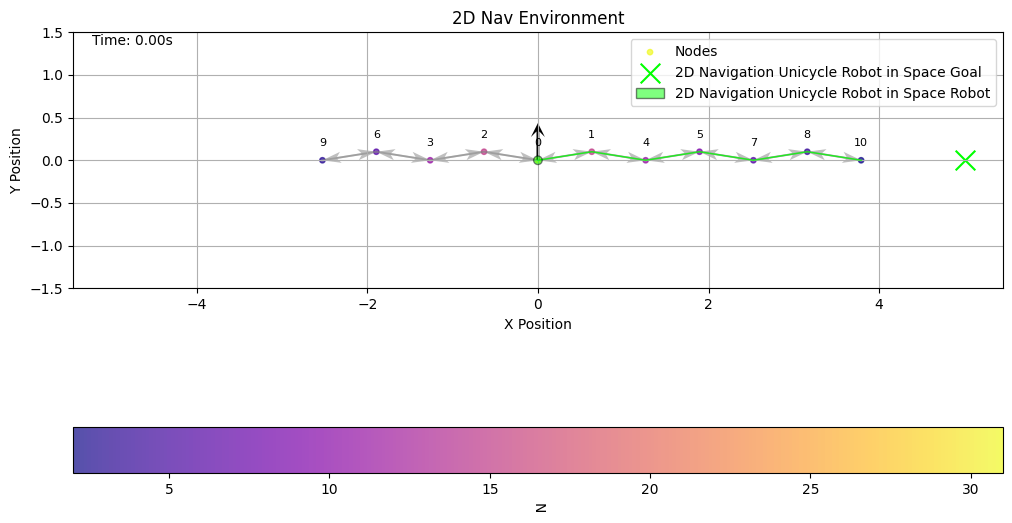

In [14]:
try:
    planner.render(scatter_mode='N')
except Exception as e:
    print(f"Error occurred while rendering: {e}")

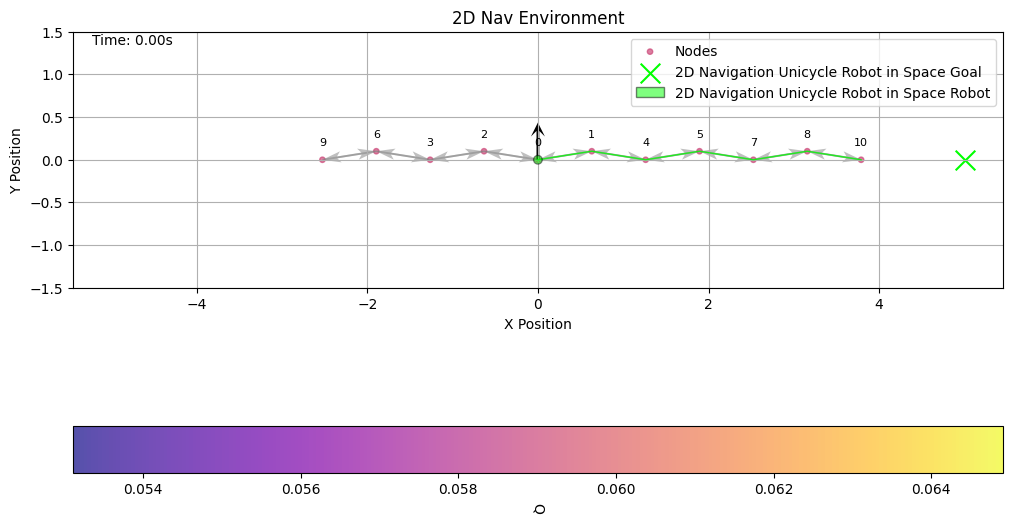

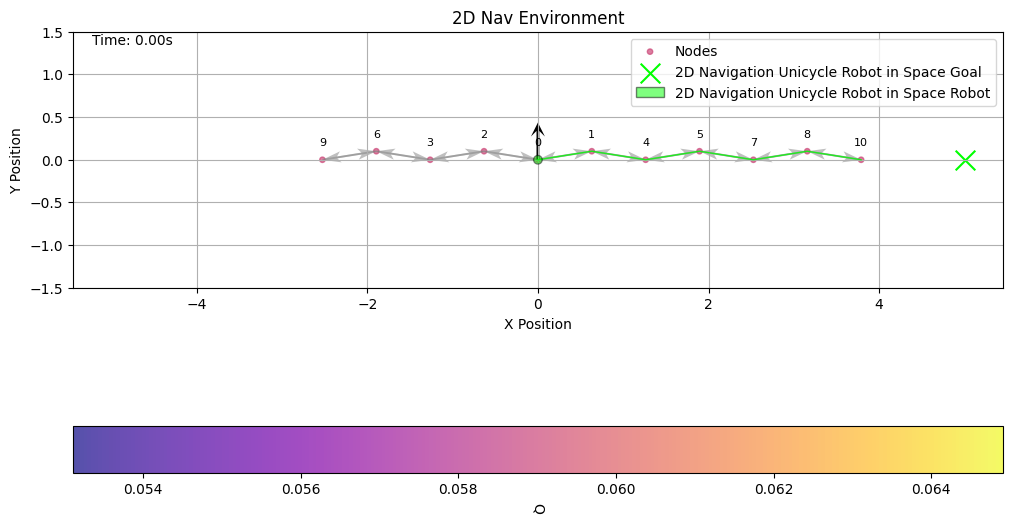

In [15]:
planner.update_trajectory_plan(*planner.yield_plan())
planner.render(scatter_mode='Q')

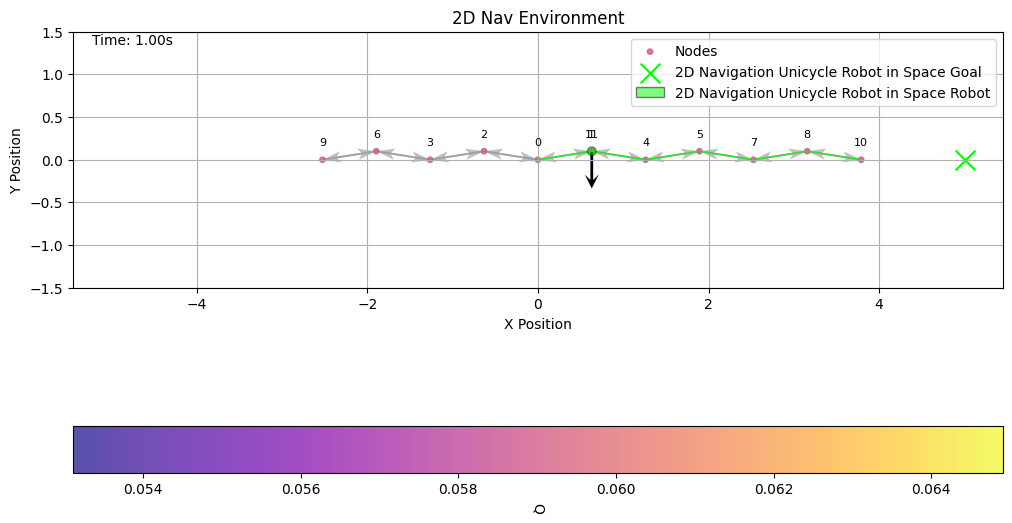

planner.planned_trajectory['action_list'][0]: [array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32)]


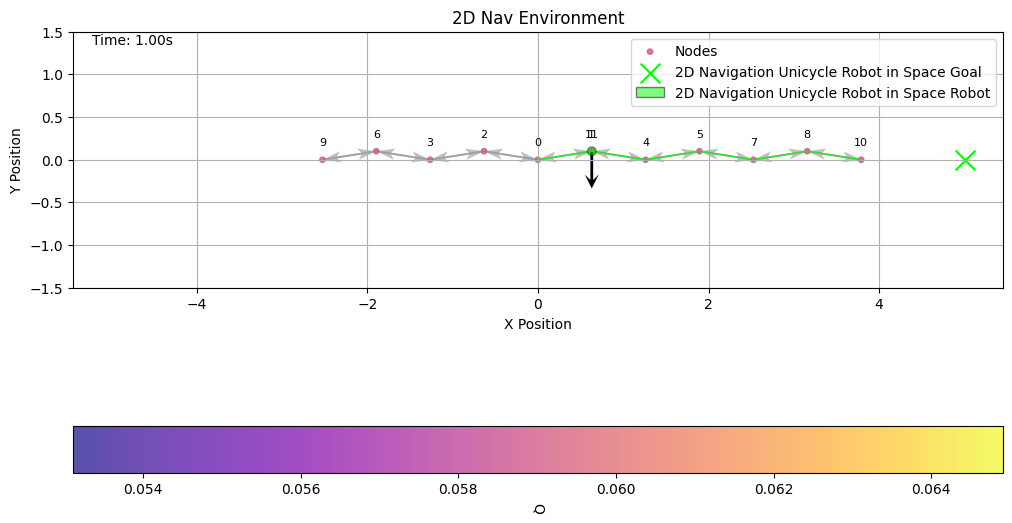

In [16]:
planner.env.multi_step(planner.planned_trajectory['action_list'][0], planner.planned_trajectory['dt_list'][0])
planner.update_planner() 
planner.render(scatter_mode='Q')
print("planner.planned_trajectory['action_list'][0]:", planner.planned_trajectory['action_list'][0])

In [17]:
planner.graph.successor_indices(planner.root_node_id)

NodeIndices[]

In [18]:
planner.plan(15)


Success: True, n_actions: 10, sum_dt: 4.228518074990216, start_state: [ 0.631375    0.09999954 -1.5707974   1.0000001 ], setpoint_state: [0.        0.        1.5707964 0.       ], final_state: [-1.11379305e-07 -6.61094700e-08  1.57079654e+00  5.22851819e+00], would_truncate: False
True Start: [ 0.631375    0.09999954 -1.5707974   1.0000001 ] Controller: [-1.11379305e-07 -6.61094700e-08  1.57079654e+00  5.22851819e+00] Setpoint: [0.        0.        1.5707964 0.       ] Would Truncate: False
Success: True, n_actions: 10, sum_dt: 4.228518074990216, start_state: [ 0.631375    0.09999954 -1.5707974   1.0000001 ], setpoint_state: [0.        0.        1.5707964 0.       ], final_state: [-1.11379305e-07 -6.61094700e-08  1.57079654e+00  5.22851819e+00], would_truncate: False
True Start: [ 0.631375    0.09999954 -1.5707974   1.0000001 ] Controller: [-1.11379305e-07 -6.61094700e-08  1.57079654e+00  5.22851819e+00] Setpoint: [0.        0.        1.5707964 0.       ] Would Truncate: False
Success:

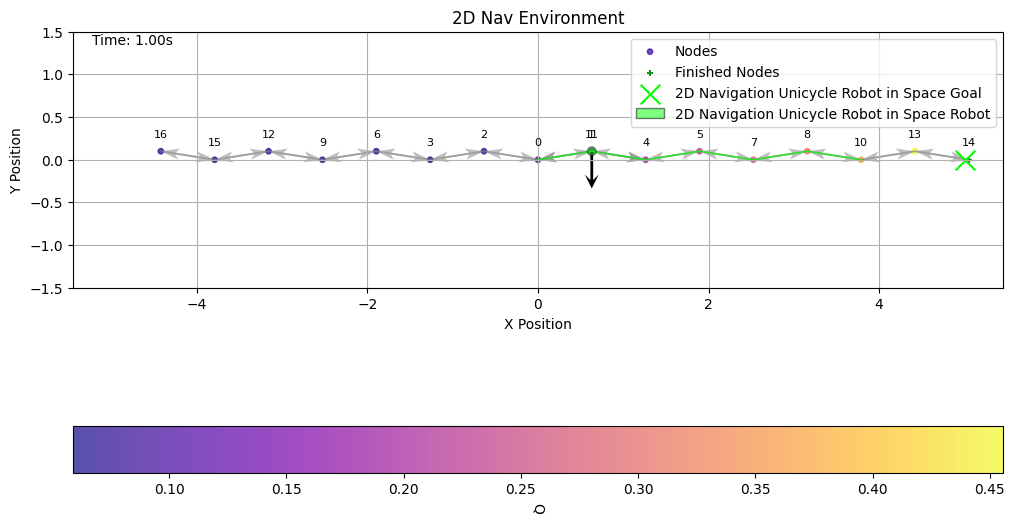

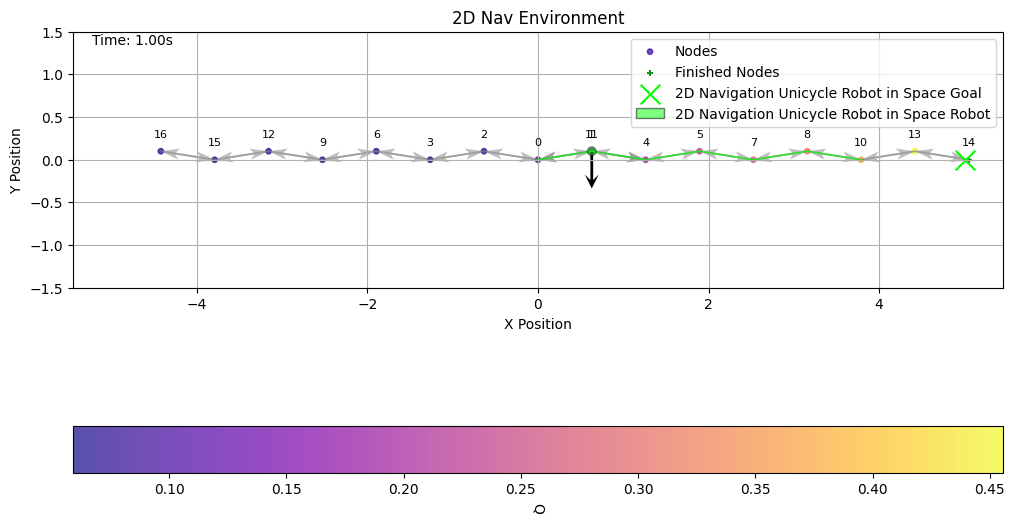

In [19]:
planner.render(scatter_mode='Q')

In [20]:

res = planner.yield_plan()
planner.update_trajectory_plan(*res)
res


Best edge tuple: (11, 4, EdgePayload(actions=[array([0.16772352, 1.99188912]), array([0.43904044, 0.33326599]), array([ 0.46773338, -0.03225755]), array([ 0.44423929, -0.221629  ]), array([ 0.40982476, -0.36299475]), array([ 0.36634145, -0.49915881]), array([ 0.30500388, -0.66588948]), array([ 0.19127132, -1.50135438]), array([ 0.15958641, -2.04237313]), array([ 0.65158167, -1.7583639 ])], dt=[np.float64(0.8540285083529274), np.float64(0.4519582440371653), np.float64(0.3980395341291279), np.float64(0.3885238731189445), np.float64(0.39646034231464794), np.float64(0.4200608218755524), np.float64(0.47006549977216067), np.float64(0.7936230288021179), np.float64(0.8278985837565159), np.float64(0.7651471313461946)], Q=None))
Best edge tuple: (4, 5, EdgePayload(actions=[array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dtype=float32), array([ 1.       , -3.1415927], dt

([11, 4, 5, 7, 8, 10, 13, 14],
 [[array([0.16772352, 1.99188912]),
   array([0.43904044, 0.33326599]),
   array([ 0.46773338, -0.03225755]),
   array([ 0.44423929, -0.221629  ]),
   array([ 0.40982476, -0.36299475]),
   array([ 0.36634145, -0.49915881]),
   array([ 0.30500388, -0.66588948]),
   array([ 0.19127132, -1.50135438]),
   array([ 0.15958641, -2.04237313]),
   array([ 0.65158167, -1.7583639 ])],
  [array([ 1.       , -3.1415927], dtype=float32),
   array([ 1.       , -3.1415927], dtype=float32),
   array([ 1.       , -3.1415927], dtype=float32),
   array([ 1.       , -3.1415927], dtype=float32),
   array([ 1.       , -3.1415927], dtype=float32),
   array([ 1.       , -3.1415927], dtype=float32),
   array([ 1.       , -3.1415927], dtype=float32),
   array([ 1.       , -3.1415927], dtype=float32),
   array([ 1.       , -3.1415927], dtype=float32),
   array([ 1.       , -3.1415927], dtype=float32)],
  [array([1.       , 3.1415927], dtype=float32),
   array([1.       , 3.1415927],

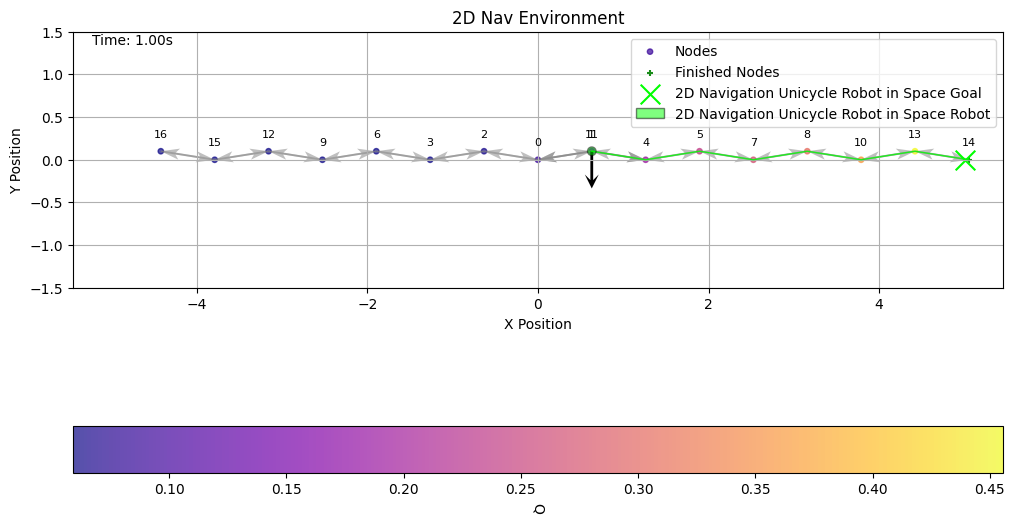

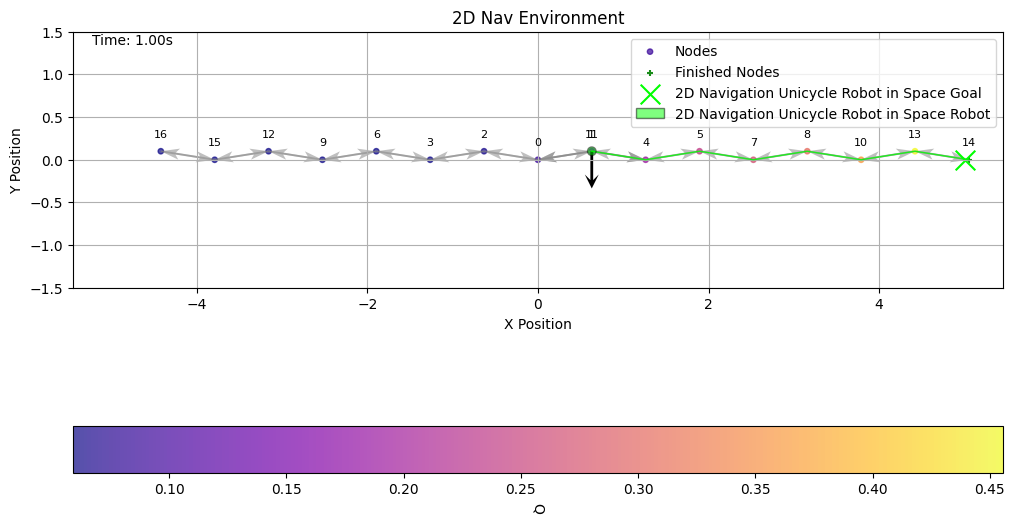

In [21]:
planner.render(scatter_mode='Q')

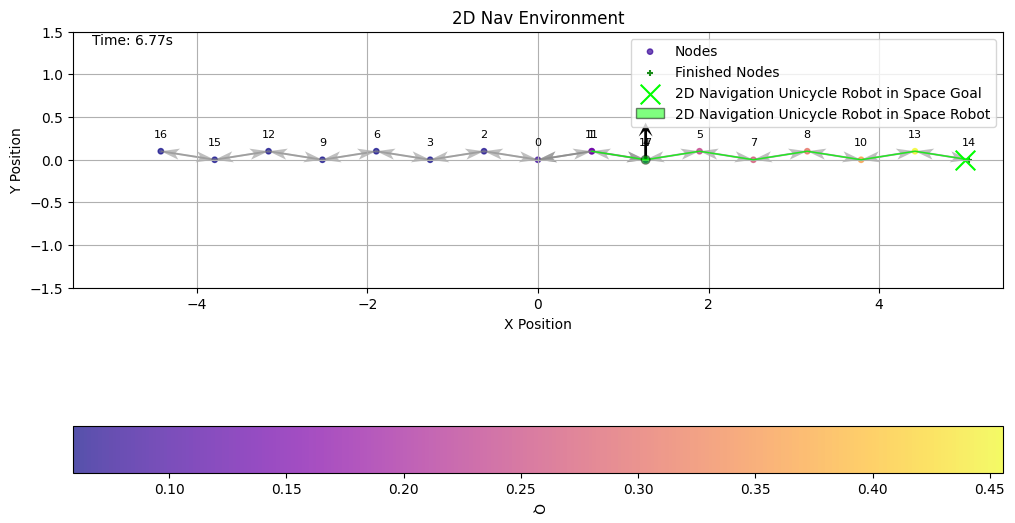

planner.planned_trajectory['action_list'][0]: [array([0.16772352, 1.99188912]), array([0.43904044, 0.33326599]), array([ 0.46773338, -0.03225755]), array([ 0.44423929, -0.221629  ]), array([ 0.40982476, -0.36299475]), array([ 0.36634145, -0.49915881]), array([ 0.30500388, -0.66588948]), array([ 0.19127132, -1.50135438]), array([ 0.15958641, -2.04237313]), array([ 0.65158167, -1.7583639 ])]
{'root_node_id': 11, 'node_ids': [11, 4, 5, 7, 8, 10, 13, 14], 'state_list': [array([ 0.631375  ,  0.09999954, -1.5707974 ,  1.0000001 ], dtype=float32), array([ 1.2627498e+00, -9.0152025e-07,  1.5707963e+00,  2.0000002e+00],
      dtype=float32), array([ 1.8941246 ,  0.09999865, -1.5707974 ,  2.9999993 ], dtype=float32), array([ 2.5254991e+00, -1.7955899e-06,  1.5707963e+00,  3.9999983e+00],
      dtype=float32), array([ 3.156874  ,  0.09999775, -1.5707974 ,  4.9999976 ], dtype=float32), array([ 3.7882488e+00, -2.6896596e-06,  1.5707963e+00,  5.9999967e+00],
      dtype=float32), array([ 4.4196234 ,

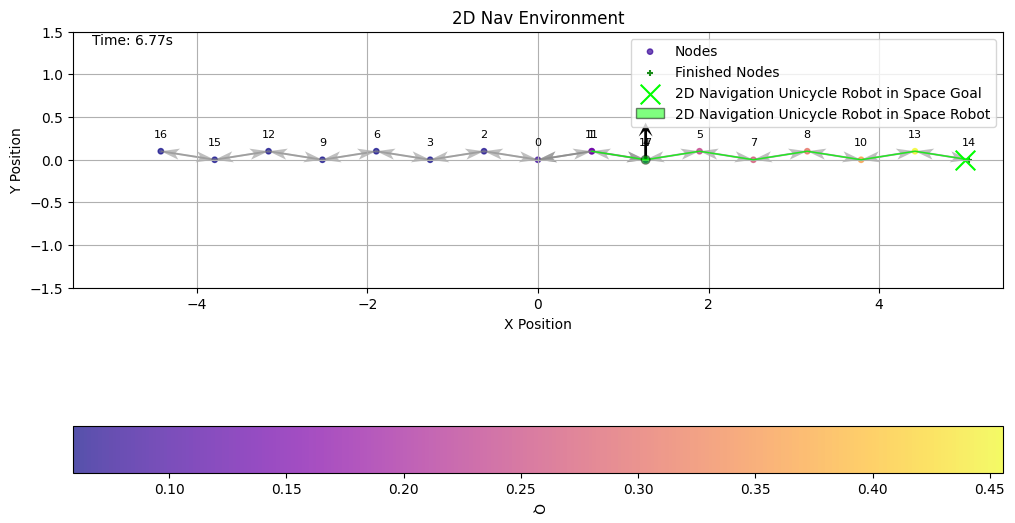

In [22]:

planner.env.multi_step(planner.planned_trajectory['action_list'][0], planner.planned_trajectory['dt_list'][0])
planner.update_planner() 
planner.render(scatter_mode='Q')
print("planner.planned_trajectory['action_list'][0]:", planner.planned_trajectory['action_list'][0])
print(planner.planned_trajectory)

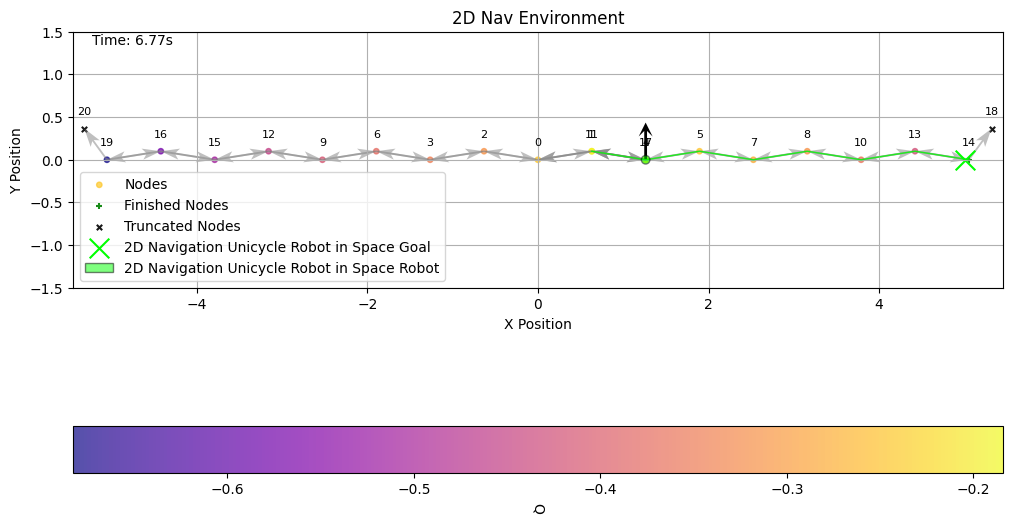

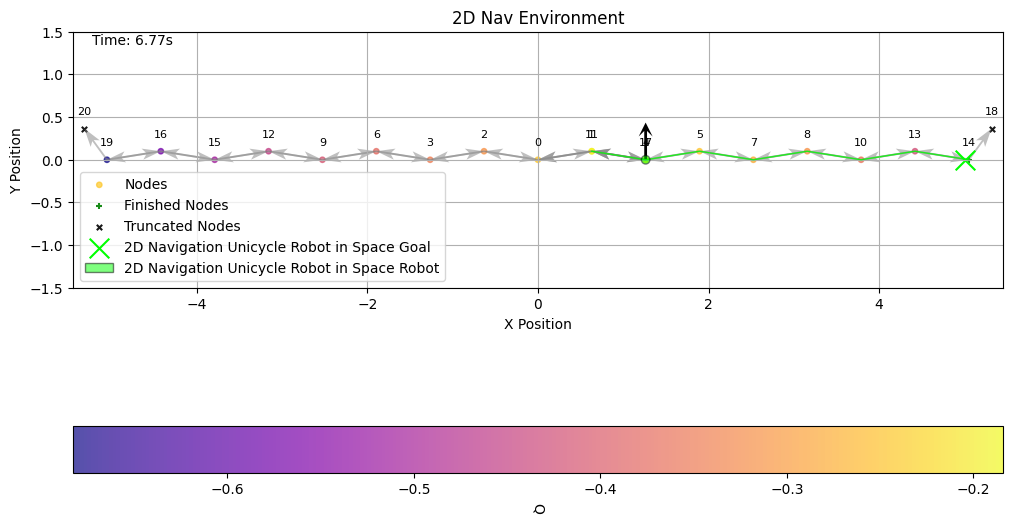

In [23]:
planner.plan(15)
planner.render(scatter_mode='Q')

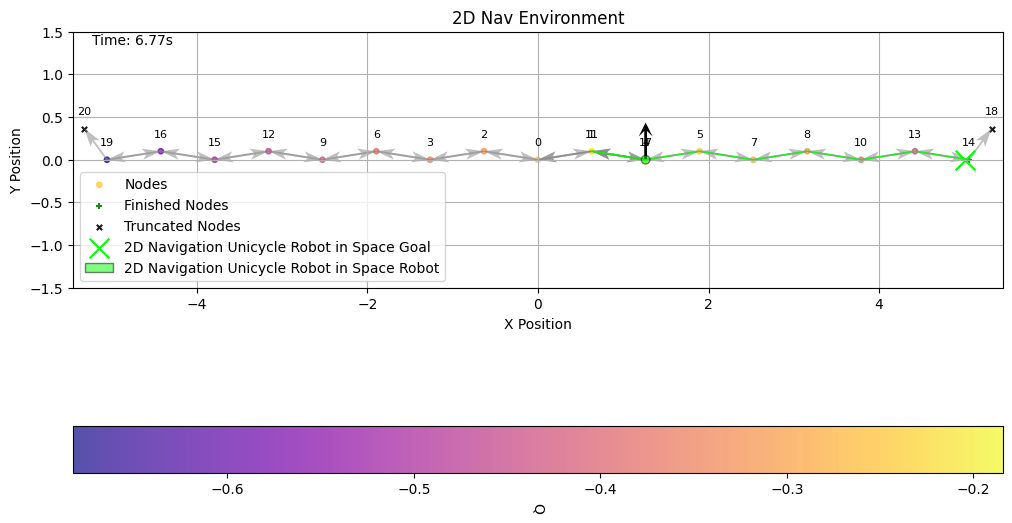

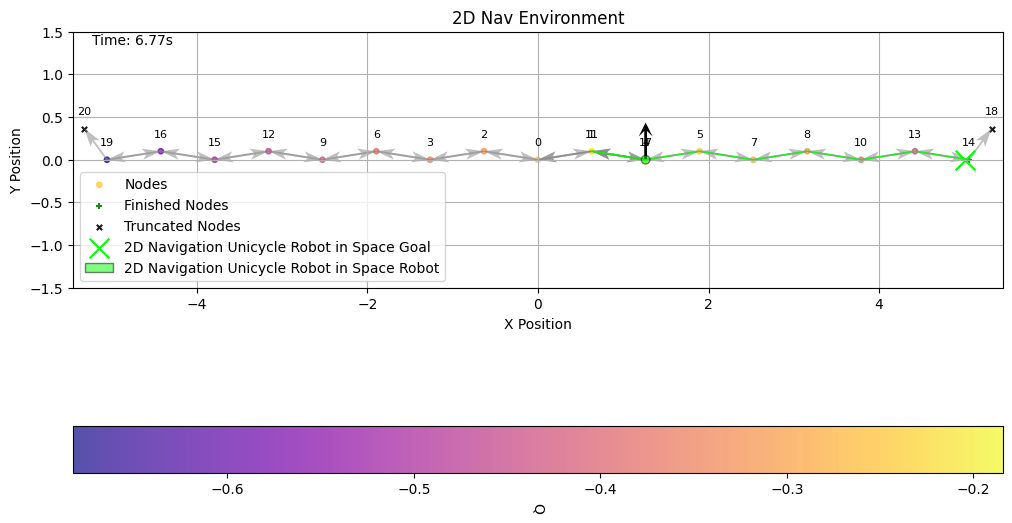

In [24]:
res = planner.yield_plan()
planner.update_trajectory_plan(*res)
planner.render()

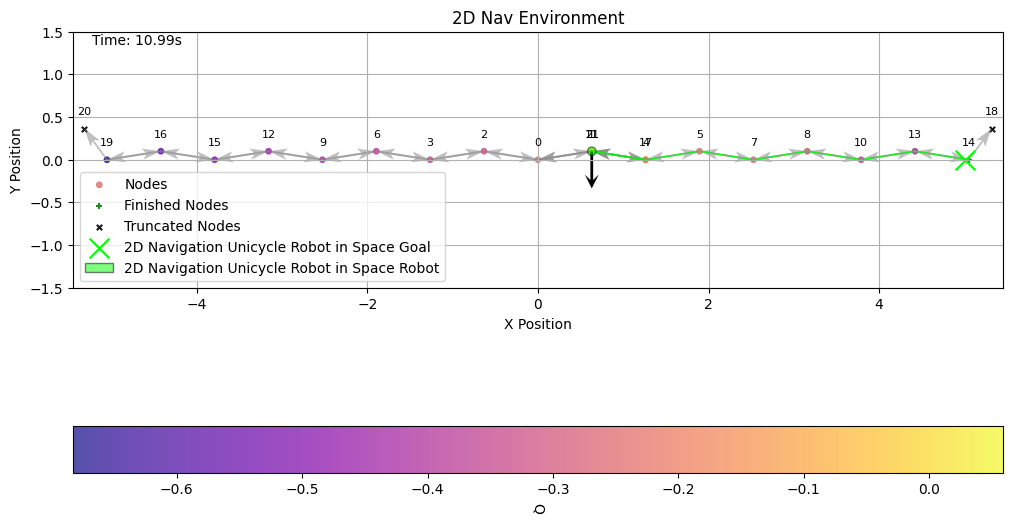

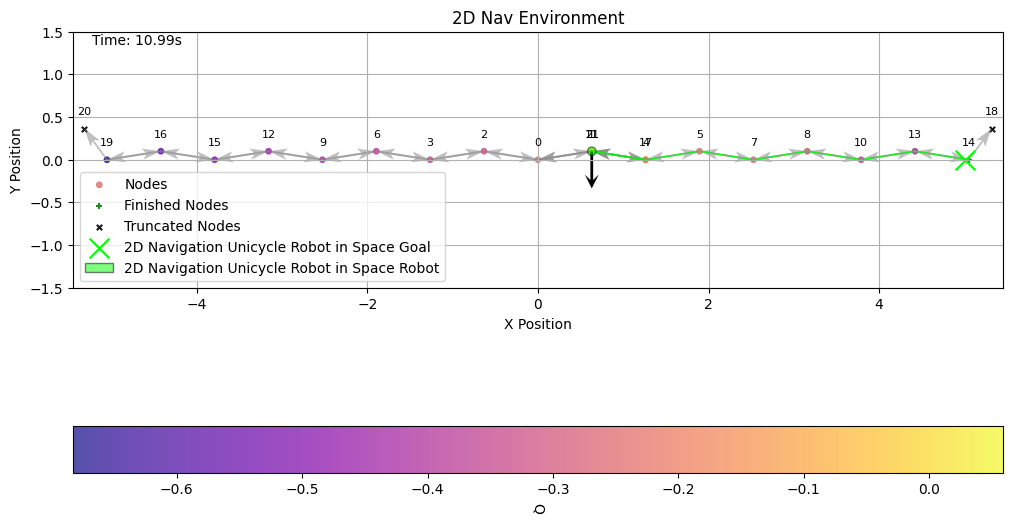

In [25]:
print("planner.planned_trajectory['action_list'][0]:", planner.planned_trajectory['action_list'][0])
planner.env.multi_step(planner.planned_trajectory['action_list'][0], planner.planned_trajectory['dt_list'][0])
planner.update_planner() 
planner.render(scatter_mode='Q')

In [26]:
planner.plan(15)


Success: True, n_actions: 10, sum_dt: 5.7659133567088565, start_state: [ 0.6313749   0.09999961 -1.57079762 10.99432367], setpoint_state: [ 1.2627498e+00 -9.0152025e-07  1.5707963e+00  2.0000002e+00], final_state: [ 1.26274978e+00 -9.93171511e-07  1.57079643e+00  1.67602370e+01], would_truncate: False
True Start: [ 0.6313749   0.09999961 -1.57079762 10.99432367] Controller: [ 1.26274978e+00 -9.93171511e-07  1.57079643e+00  1.67602370e+01] Setpoint: [ 1.2627498e+00 -9.0152025e-07  1.5707963e+00  2.0000002e+00] Would Truncate: False
Success: True, n_actions: 10, sum_dt: 5.765365038704479, start_state: [ 0.6313749   0.09999961 -1.57079762 10.99432367], setpoint_state: [ 1.26274978e+00 -9.93169315e-07  1.57079643e+00  6.76580569e+00], final_state: [ 1.26274976e+00 -1.08480891e-06  1.57079660e+00  1.67596887e+01], would_truncate: False
True Start: [ 0.6313749   0.09999961 -1.57079762 10.99432367] Controller: [ 1.26274976e+00 -1.08480891e-06  1.57079660e+00  1.67596887e+01] Setpoint: [ 1.262

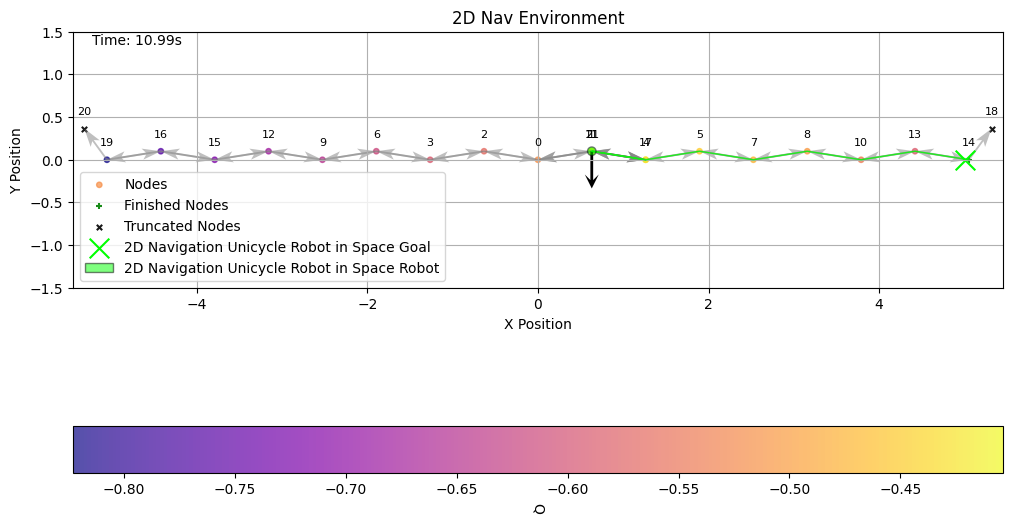

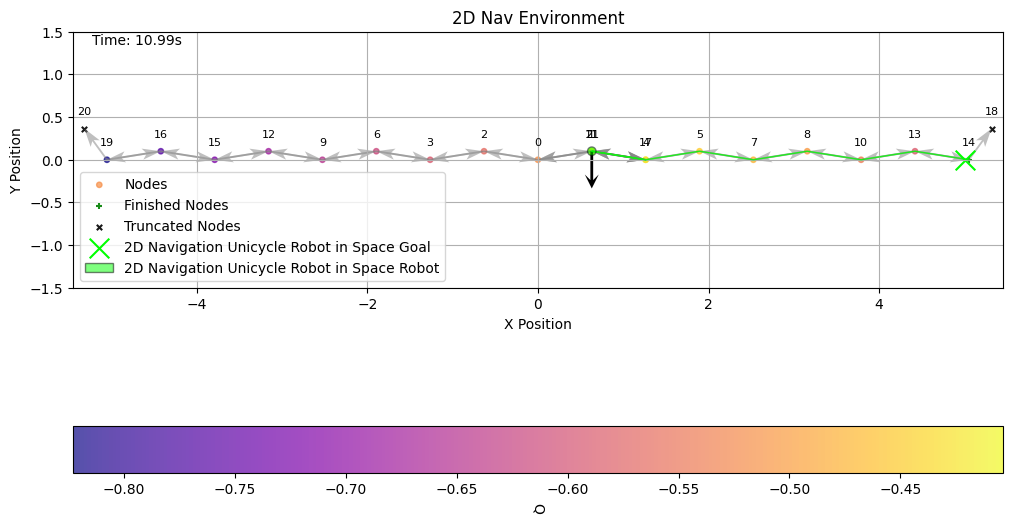

In [27]:
planner.render()

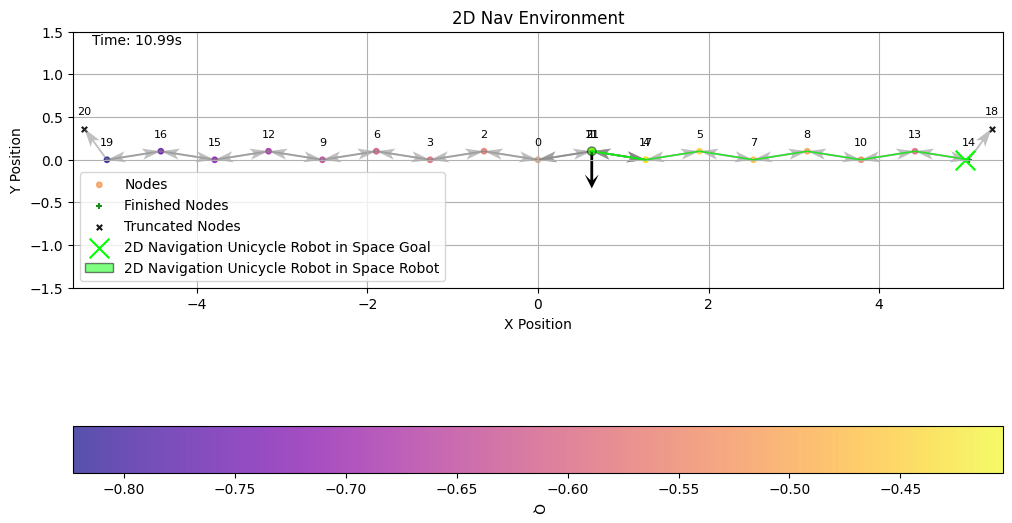

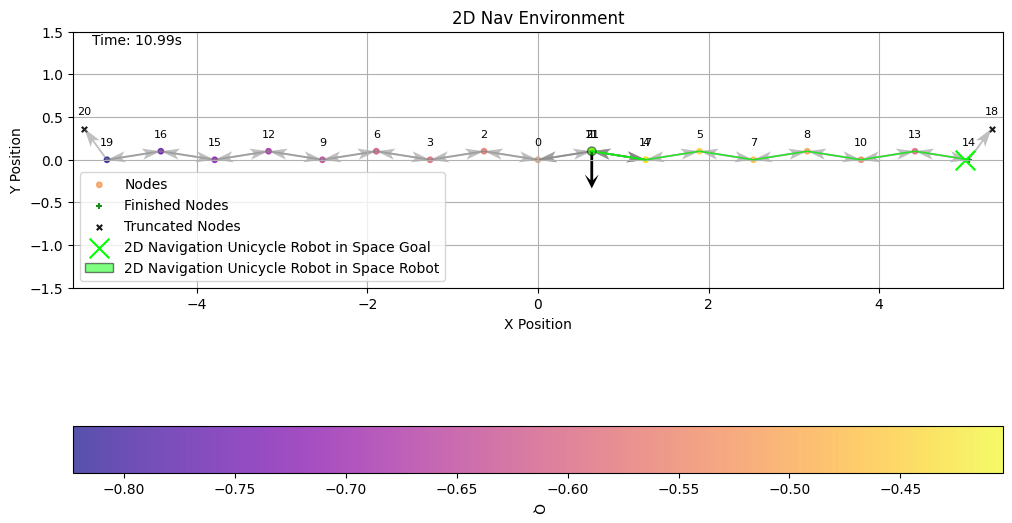

In [28]:
res = planner.yield_plan()
planner.update_trajectory_plan(*res)
planner.render()

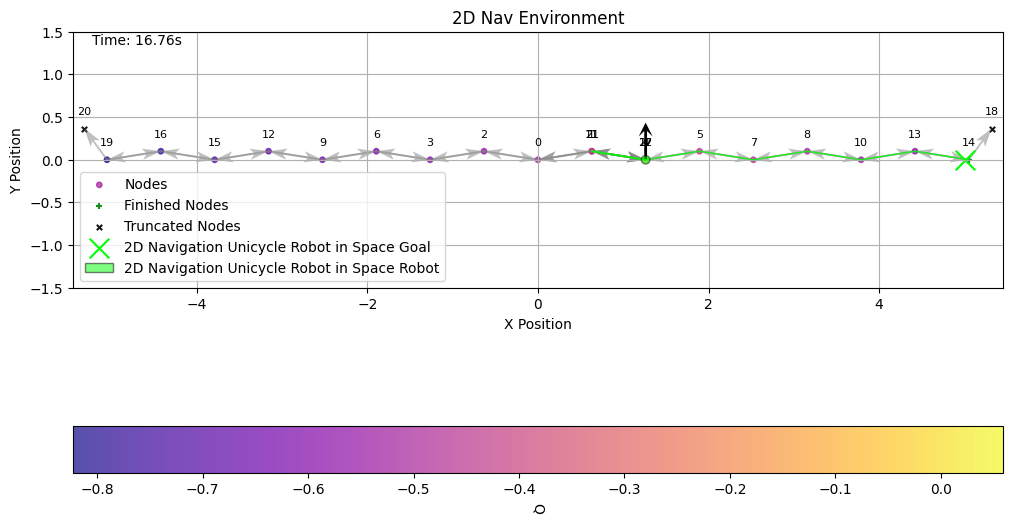

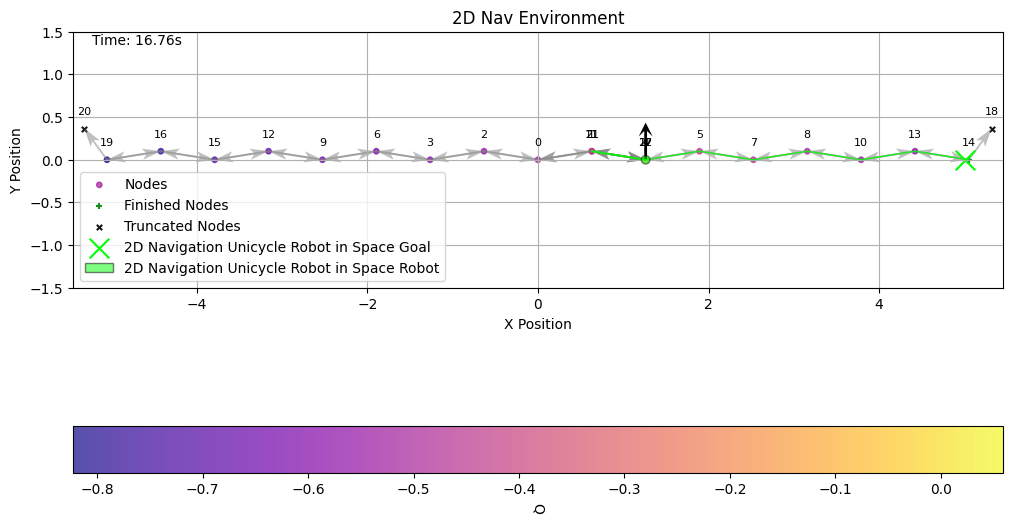

In [29]:
planner.planned_trajectory['action_list'][0]
planner.env.multi_step(planner.planned_trajectory['action_list'][0], planner.planned_trajectory['dt_list'][0])
planner.update_planner() 
planner.render(scatter_mode='Q')

In [30]:
# planner.reset()
# planner.plan(expand_n_times=1)
# plan, plan_action_list, plan_dt_list = planner.yield_plan()
# planner.update_trajectory_plan(plan)


# planner.render()
# print("Planned trajectory:", len(plan), len(plan_action_list), len(plan_dt_list))
# print("Actions per step:", [len(a) for a in plan_action_list], [len(dt) for dt in plan_dt_list])
# print("Next state:", planner.graph[plan[1]].state)

In [31]:
def get_stats():
    c_truncated = 0
    c_N_truncated = 0
    c_N_stats = np.zeros(100, dtype=np.int64)
    c_N_finished = 0
    for node in list(planner.graph.nodes()):
        c_N_stats[min(node.N, 99)] += 1
        if node.is_truncated:
            c_truncated += 1
            c_N_truncated += node.N
        if node.is_finished:
            c_N_finished += 1
            print(f"Finished node at state {node.state} with N={node.N}")
            sleep(0.1)
    print(f"Truncated nodes: {c_truncated}/{len(planner.graph.nodes())}, N={c_N_truncated}")
    print(f"Finished nodes: {c_N_finished}/{len(planner.graph.nodes())}")
    print(c_N_stats)

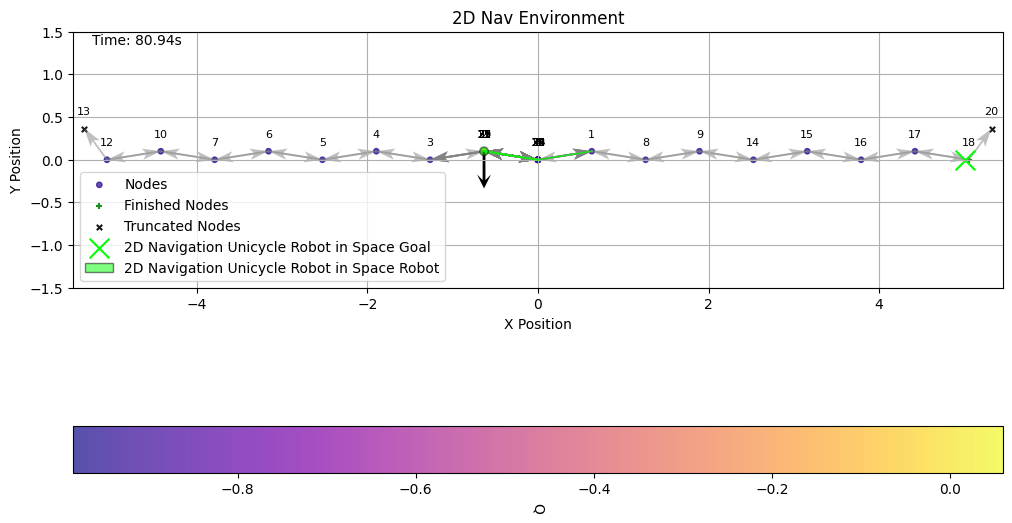

Iteration 16: current state: [-0.6313752   0.10000039 -1.57079577 80.94167643], plan: [35], actions: [], dts: []
Computational budget used: 30/510
Time budget used: 1.0003/15.5295
Step 16: took action [] to [-0.6313752   0.10000039 -1.5707958  80.94167   ], got reward 0.01, terminated=False, truncated=False
Node count: 36, Edge count: 107
--- Iteration 17 ---
Agent state: [-0.6313752   0.10000039 -1.57079577 80.94167643]
Success: True, n_actions: 10, sum_dt: 5.763698845648211, start_state: [-0.6313752   0.10000039 -1.57079577 80.94167643], setpoint_state: [-1.2627501e+00 -4.6938658e-07  1.5707963e+00  2.0000002e+00], final_state: [-1.26275018e+00 -6.25653955e-07  1.57079625e+00  8.67053753e+01], would_truncate: False
True Start: [-0.6313752   0.10000039 -1.57079577 80.94167643] Controller: [-1.26275018e+00 -6.25653955e-07  1.57079625e+00  8.67053753e+01] Setpoint: [-1.2627501e+00 -4.6938658e-07  1.5707963e+00  2.0000002e+00] Would Truncate: False
Success: True, n_actions: 10, sum_dt: 4

In [ ]:
episode_over = False
total_reward = 0

planner.reset()
try:
    # planner.plan(iterations=20, expand_n_times=10) # Bootstrapping
    pass
except Exception as e:
    print("Exception during bootstrapping planning:")
    print(e)
# planner.plan_while_in_budget()
i = 0
while not episode_over:
    print(f"--- Iteration {i} ---")

    # planner.plan(iterations=250, expand_n_times=1)
    print("Agent state:", planner.env.agent.state)
    observation, reward, terminated, truncated, info = planner.plan_and_step(render=False, computational=True, time=True)
    print("Agent state after step:", planner.env.agent.state)
    sleep(1.0) 
    planner.render()
    sleep(3.0)
    try:
        # get_stats()
        plan, plan_action_list, plan_dt_list = planner.yield_plan(max_length=100)
        print(f"Iteration {i}: current state: {planner.env.agent.state}, plan: {plan}, actions: {plan_action_list}, dts: {plan_dt_list}")
        print(f"Computational budget used: {planner.computational_budget_used}/{planner.computational_budget_total}")
        print(f"Time budget used: {planner.time_budget_used:.4f}/{planner.time_budget_total:.4f}")
        print(f"Step {i}: took action {plan_action_list} to {observation}, got reward {reward}, terminated={terminated}, truncated={truncated}")
        print(f"Node count: {planner.graph.num_nodes()}, Edge count: {planner.graph.num_edges()}")
    except Exception as e:
        print(f"Iteration {i}: current state: {planner.env.agent.state}, no plan found!")
        print(e)
        sleep(2.0)

    total_reward += reward
    episode_over = terminated or truncated
    i += 1
    # sleep(5)
    if i >= 50:
        print("Stopping after 50 iterations.")
        break
planner.render()
print(f"Episode finished! Total reward: {total_reward} after {i} iterations with computational budget used {planner.computational_budget_used}/{planner.computational_budget_total}")

env.close()


In [ ]:
np.random.randint(low=0, high=1)

0

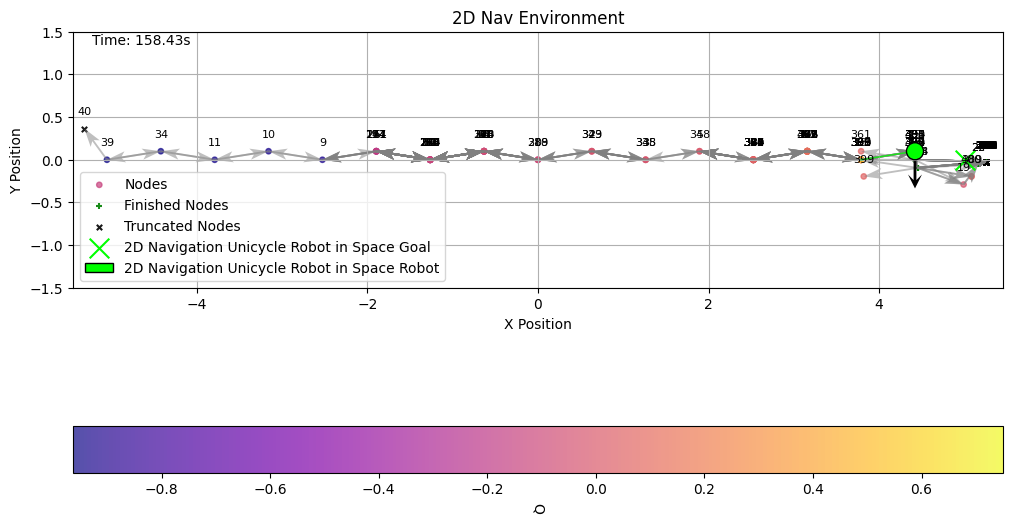

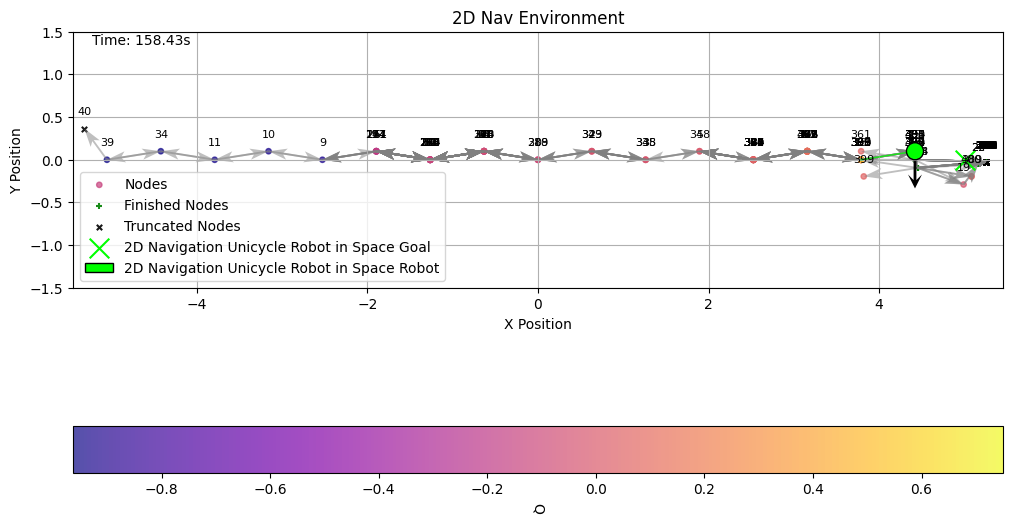

In [ ]:
planner.render()

In [ ]:
planner.graph[planner.root_node_id]

NodePayload(id=404, state=[ 4.41962509e+00  9.99955763e-02 -1.57079762e+00  1.58429434e+02], N=1, U=1.9602, Q=1.9602, is_finished=True, is_truncated=False)

In [ ]:
planner.env.observation_space

Box([-5.25      -1.5       -3.1415927  0.       ], [5.25      1.5       3.1415927       inf], (4,), float32)

In [ ]:
planner.observation_replay

[array([0.       , 0.       , 1.5707964, 0.       ], dtype=float32),
 array([-0.6313751 ,  0.09999976, -1.5707958 ,  1.0000001 ], dtype=float32),
 array([-1.2627501e+00, -6.2564112e-07,  1.5707963e+00,  6.7643785e+00],
       dtype=float32),
 array([-0.6313751 ,  0.09999976, -1.5707958 , 10.992896  ], dtype=float32),
 array([-1.2627503e+00, -7.8187463e-07,  1.5707963e+00,  1.6756332e+01],
       dtype=float32),
 array([-0.6313751 ,  0.09999976, -1.5707958 , 20.98485   ], dtype=float32),
 array([-1.2627503e+00, -7.8187463e-07,  1.5707963e+00,  2.6748287e+01],
       dtype=float32),
 array([-0.6313751 ,  0.09999976, -1.5707958 , 30.976805  ], dtype=float32),
 array([-1.2627503e+00, -7.8187463e-07,  1.5707963e+00,  3.6740238e+01],
       dtype=float32),
 array([-0.6313751 ,  0.09999976, -1.5707958 , 40.968758  ], dtype=float32),
 array([-1.2627503e+00, -7.8187463e-07,  1.5707963e+00,  4.6732193e+01],
       dtype=float32),
 array([-0.6313751 ,  0.09999976, -1.5707958 , 50.960712  ], dtype

In [ ]:
np.random.random(size=(20,3),) * np.array([10,6,1]).round(decimals=2)

array([[4.27259963, 2.55331634, 0.01642004],
       [2.49704008, 4.92284059, 0.61821061],
       [4.00839883, 4.80290994, 0.23446092],
       [7.49618736, 1.88587202, 0.10425176],
       [6.77888378, 3.84794465, 0.04623441],
       [5.18461185, 4.43405331, 0.81271852],
       [8.57823233, 5.75556608, 0.79591162],
       [6.63296816, 4.25370382, 0.33186241],
       [6.1985492 , 5.33654311, 0.64156765],
       [2.91423901, 1.49653682, 0.84623987],
       [9.02331467, 2.10592613, 0.89103281],
       [7.12655281, 1.34106031, 0.70951018],
       [4.46645825, 0.73086342, 0.59569603],
       [4.34955163, 0.18501081, 0.19240982],
       [9.5007099 , 1.43180021, 0.38695021],
       [7.46112403, 3.2452504 , 0.64184703],
       [5.33117584, 5.92679287, 0.92940936],
       [9.73411666, 3.36970784, 0.55598414],
       [4.74523546, 1.0758452 , 0.02634139],
       [3.4452019 , 4.41536531, 0.37816785]])